## 1. Business Problem

### Objective

The goal of this project is to evaluate Microsoft Corporation from an investment perspective and determine whether the company represents an attractive long-term investment opportunity.

This analysis aims to assess Microsoft's financial performance, profitability, financial health, growth potential, valuation, and key investment risks.

The final objective is to provide an investment recommendation based on quantitative financial analysis and publicly available financial data.

## 2. Company Overview


### Company Description

Microsoft Corporation is a global technology company that develops, licenses, and supports a wide range of software, cloud computing services, devices, and digital solutions.

The company operates worldwide and serves individual consumers, businesses, and government organizations.


### Business Segments

Microsoft operates through three major business segments:

1. Productivity and Business Processes
- Microsoft Office
- Microsoft 365
- LinkedIn
- Dynamics

2. Intelligent Cloud
- Azure cloud platform
- Server products
- Enterprise services

3. More Personal Computing
- Windows
- Xbox
- Surface devices
- Gaming services

### Competitive Position

Microsoft maintains a strong competitive position due to its ecosystem of enterprise software, cloud infrastructure, and artificial intelligence investments.

The company competes with major technology firms such as Apple, Amazon, and Alphabet.


### Investment Relevance

Microsoft is selected for this investment analysis because it represents one of the world's largest technology companies with significant exposure to cloud computing, artificial intelligence, and enterprise software markets.

The company provides an interesting case study for evaluating long-term growth, profitability, and valuation.

## 3. Data Collection

The financial data used in this project is collected from Yahoo Finance using the Python library `yfinance`.

The dataset includes:
- Company information
- Income Statement
- Balance Sheet
- Cash Flow Statement
- Historical stock prices

These datasets will be used to evaluate Microsoft's financial performance, profitability, financial health, and valuation.

In [126]:
import yfinance as yf
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [19]:
msft = yf.Ticker('MSFT')
info = msft.info

info

{'address1': 'One Microsoft Way',
 'city': 'Redmond',
 'state': 'WA',
 'zip': '98052-6399',
 'country': 'United States',
 'phone': '425 882 8080',
 'website': 'https://www.microsoft.com',
 'industry': 'Software - Infrastructure',
 'industryKey': 'software-infrastructure',
 'industryDisp': 'Software - Infrastructure',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Microsoft Corporation develops and supports software, services, devices, and solutions worldwide. The Productivity and Business Processes segment offers Microsoft 365 commercial, enterprise mobility + security, windows commercial, power BI, exchange, sharepoint, Microsoft teams, security and compliance, and copilot; Microsoft 365 commercial products, such as Windows commercial on-premises and office licensed services; Microsoft 365 consumer products and cloud services, including Microsoft 365 consumer subscriptions, office licensed on-premises, and other consumer serv

In [21]:
print(f"Company: {info['longName']}")
print(f"Sector: {info['sector']}")
print(f"Industry: {info['industry']}")
print(f"Country: {info['country']}")
print(f"Market Cap: {info['marketCap']:,}")

Company: Microsoft Corporation
Sector: Technology
Industry: Software - Infrastructure
Country: United States
Market Cap: 2,925,466,222,592


In [22]:
income_statement = msft.financials
balance_sheet = msft.balance_sheet
cash_flow = msft.cashflow

In [28]:
income_statement

,2025-06-30,2024-06-30,2023-06-30,2022-06-30
Tax Effect Of Unusual Items,-7.708800e+07,-9.991800e+07,-2.850000e+06,4.375400e+07
Tax Rate For Calcs,1.760000e-01,1.820000e-01,1.900000e-01,1.310000e-01
Normalized EBITDA,1.606030e+11,1.335580e+11,1.051550e+11,9.990500e+10
Total Unusual Items,-4.380000e+08,-5.490000e+08,-1.500000e+07,3.340000e+08
Total Unusual Items Excluding Goodwill,-4.380000e+08,-5.490000e+08,-1.500000e+07,3.340000e+08
Net Income From Continuing Operation Net Minority Interest,1.018320e+11,8.813600e+10,7.236100e+10,7.273800e+10
Reconciled Depreciation,3.415300e+10,2.228700e+10,1.386100e+10,1.446000e+10
Reconciled Cost Of Revenue,8.783100e+10,7.411400e+10,6.586300e+10,6.265000e+10
EBITDA,1.601650e+11,1.330090e+11,1.051400e+11,1.002390e+11
EBIT,1.260120e+11,1.107220e+11,9.127900e+10,8.577900e+10


## 4. Financial Performance Analysis

### 4.1 Selecting Financial Metrics


In [31]:
income_statement.index.tolist()

['Tax Effect Of Unusual Items',
 'Tax Rate For Calcs',
 'Normalized EBITDA',
 'Total Unusual Items',
 'Total Unusual Items Excluding Goodwill',
 'Net Income From Continuing Operation Net Minority Interest',
 'Reconciled Depreciation',
 'Reconciled Cost Of Revenue',
 'EBITDA',
 'EBIT',
 'Net Interest Income',
 'Interest Expense',
 'Interest Income',
 'Normalized Income',
 'Net Income From Continuing And Discontinued Operation',
 'Total Expenses',
 'Total Operating Income As Reported',
 'Diluted Average Shares',
 'Basic Average Shares',
 'Diluted EPS',
 'Basic EPS',
 'Diluted NI Availto Com Stockholders',
 'Net Income Common Stockholders',
 'Net Income',
 'Net Income Including Noncontrolling Interests',
 'Net Income Continuous Operations',
 'Tax Provision',
 'Pretax Income',
 'Other Income Expense',
 'Other Non Operating Income Expenses',
 'Special Income Charges',
 'Write Off',
 'Gain On Sale Of Security',
 'Net Non Operating Interest Income Expense',
 'Interest Expense Non Operating',


#### Selected Financial Metrics

To evaluate Microsoft's financial performance, five key financial metrics were selected from the Income Statement.

These metrics provide a comprehensive view of the company's revenue generation, profitability, and operating performance.

- **Total Revenue** – measures the total amount of income generated from Microsoft's business operations. It helps assess whether the company is growing over time.

- **Gross Profit** – represents the profit remaining after deducting the cost of revenue. It indicates how efficiently Microsoft generates profit from its products and services.

- **Operating Income** – measures profit generated from the company's core business operations before interest and taxes. It reflects operational efficiency.

- **Net Income** – represents the company's final profit after all operating expenses, interest, and taxes. It is one of the most important indicators for shareholders.

- **EBITDA** – measures earnings before interest, taxes, depreciation, and amortization. It is widely used to compare the operating performance of companies across the same industry.

In [41]:
# Select the key financial metrics
key_metrics = [
    "Total Revenue",
    "Gross Profit",
    "Operating Income",
    "Net Income",
    "EBITDA"
]

# Extract the selected metrics
financial_performance = income_statement.loc[key_metrics]

# Transpose the table
financial_performance = financial_performance.T

# Convert the index from full dates to fiscal years
financial_performance.index = financial_performance.index.year

# Sort years chronologically
financial_performance = financial_performance.sort_index()

# Convert values to billions of USD
financial_performance = financial_performance / 1e9

# Round values to two decimal places
financial_performance = financial_performance.round(2)

financial_performance

,Total Revenue,Gross Profit,Operating Income,Net Income,EBITDA
2022,198.27,135.62,83.38,72.74,100.24
2023,211.92,146.05,88.52,72.36,105.14
2024,245.12,171.01,109.43,88.14,133.01
2025,281.72,193.89,128.53,101.83,160.16


### 4.2 Year-over-Year Growth Analysis


After selecting the key financial metrics, the next step is to evaluate how these indicators have changed over time.

Year-over-year (YoY) growth measures the percentage change between two consecutive fiscal years. This analysis helps identify whether Microsoft's financial performance is improving, slowing down, or declining.

The following table presents the annual growth rates for the selected financial metrics, providing additional insights into the company's financial trends and overall performance.

In [77]:
change_over_year = financial_performance.pct_change()*100

change_over_year = change_over_year.round(2)

change_over_year = change_over_year.drop(2022)

change_over_year

,Total Revenue,Gross Profit,Operating Income,Net Income,EBITDA
2023,6.88,7.69,6.16,-0.52,4.89
2024,15.67,17.09,23.62,21.81,26.51
2025,14.93,13.38,17.45,15.53,20.41


### 4.3 Revenue Analysis


Revenue represents the total income generated by Microsoft from its products and services before deducting expenses.

Analyzing revenue trends helps evaluate the company's business growth, market expansion, and ability to increase sales over time.

This section examines Microsoft's revenue performance across the analyzed fiscal years and evaluates the annual growth rate of revenue.

In [115]:
revenue_analysis = financial_performance[
    ["Total Revenue"]
]

revenue_analysis

,Total Revenue
2022,198.27
2023,211.92
2024,245.12
2025,281.72


In [121]:
revenue_analysis = revenue_analysis.copy()

revenue_analysis["YoY Growth (%)"] = (
    revenue_analysis["Total Revenue"]
    .pct_change()
    .mul(100)
    .round(2)
)

revenue_analysis

,Total Revenue,YoY Growth (%)
2022,198.27,NaN
2023,211.92,6.88
2024,245.12,15.67
2025,281.72,14.93


#### Revenue Trend Visualization

The following chart illustrates Microsoft's revenue growth over the analyzed fiscal years.

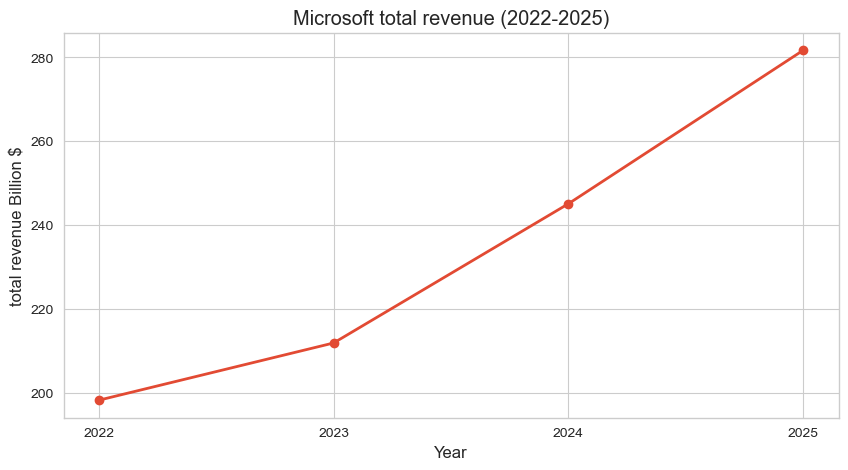

In [127]:
plt.figure(figsize = (10,5))
plt.plot(
    revenue.index,
    revenue.values,
    marker = 'o',
    linewidth = 2
)

plt.title('Microsoft total revenue (2022-2025)')
plt.xlabel('Year')
plt.ylabel('total revenue Billion $')
plt.xticks(revenue.index)
plt.grid(True)
plt.show()

#### Interpretation

Microsoft demonstrated consistent revenue growth throughout the analyzed period.

Total revenue increased from $198.3 billion in fiscal year 2022 to $281.7 billion in fiscal year 2025, representing significant business expansion over the four-year period.

The strongest year-over-year growth was observed in fiscal year 2024, when revenue increased by approximately 15.7%. Revenue growth remained strong in 2025 with a further increase of approximately 14.9%.

The sustained revenue growth indicates Microsoft's ability to expand its business operations and maintain strong demand for its products and services.

### 4.4 Gross Profit Analysis



Gross Profit represents the revenue remaining after subtracting the cost of revenue.

Analyzing gross profit helps evaluate Microsoft's ability to generate profit from its products and services before considering operating expenses.

In addition to analyzing gross profit growth, the gross profit margin is calculated to measure how efficiently the company converts revenue into gross profit.

In [109]:
gross_profit_analysis = financial_performance[
    ["Gross Profit"]
]

gross_profit_analysis

,Gross Profit
2022,135.62
2023,146.05
2024,171.01
2025,193.89


While gross profit measures the absolute amount of profit generated after deducting the cost of revenue, gross profit margin evaluates profitability relative to total revenue.

***Gross profit margin*** is calculated as the percentage of revenue that remains after covering the direct costs associated with producing Microsoft's products and services.

The formula used is:

$$
\text{Gross Profit Margin} = \frac{\text{Gross Profit}}{\text{Total Revenue}} \times 100
$$

This metric helps assess Microsoft's pricing power, cost efficiency, and the sustainability of its business model.

In [133]:
gross_profit_margin = (
    financial_performance["Gross Profit"]
    /
    financial_performance["Total Revenue"]
    *
    100
)

gross_profit_margin = gross_profit_margin.round(2)

gross_profit_margin

2022    68.40
2023    68.92
2024    69.77
2025    68.82
dtype: float64

#### Gross Profit Margin Trend Visualization

The following chart illustrates the changes in Microsoft's gross profit margin over the analyzed fiscal years.

Analyzing the trend helps evaluate whether the company is maintaining its profitability and cost efficiency over time.

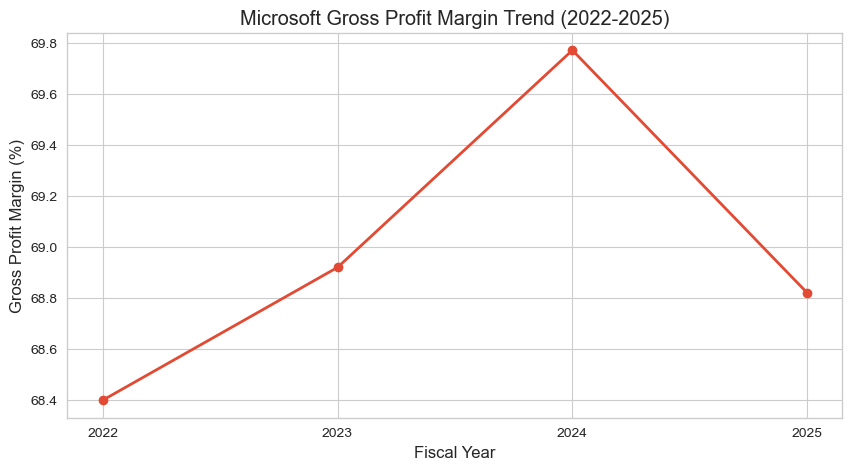

In [135]:
plt.figure(figsize=(10,5))

plt.plot(
    gross_profit_margin.index,
    gross_profit_margin.values,
    marker="o",
    linewidth=2
)

plt.title("Microsoft Gross Profit Margin Trend (2022-2025)")
plt.xlabel("Fiscal Year")
plt.ylabel("Gross Profit Margin (%)")

plt.xticks(gross_profit_margin.index)

plt.grid(True)

plt.show()

***Interpretation***

Microsoft maintained a consistently strong gross profit margin throughout the analyzed period.

The gross profit margin increased from 68.40% in fiscal year 2022 to 69.77% in 2024, indicating improved cost efficiency and strong profitability of the company's products and services.

In fiscal year 2025, the gross profit margin slightly decreased to 68.82%, but remained close to previous levels. This suggests that Microsoft continues to maintain strong pricing power and effective control over direct costs.

Overall, the stable gross profit margin demonstrates the strength and sustainability of Microsoft's business model.

### 4.5 Operating Income Analysis


Operating income represents the profit generated from Microsoft's core business operations after deducting operating expenses such as research and development, sales and marketing, and general administrative costs.

Analyzing operating income helps evaluate the company's operational efficiency and ability to generate profit from its primary business activities.

This section examines Microsoft's operating income trend and evaluates changes in operating profitability over time.

In [145]:
operating_income = financial_performance[
    ["Operating Income"]
]

operating_income

,Operating Income
2022,83.38
2023,88.52
2024,109.43
2025,128.53


**Operating Income Trend Visualization**

The following chart illustrates Microsoft's operating income over the analyzed fiscal years.

Visualizing the trend helps identify whether the company has consistently improved its operating profitability and maintained efficient management of operating expenses.

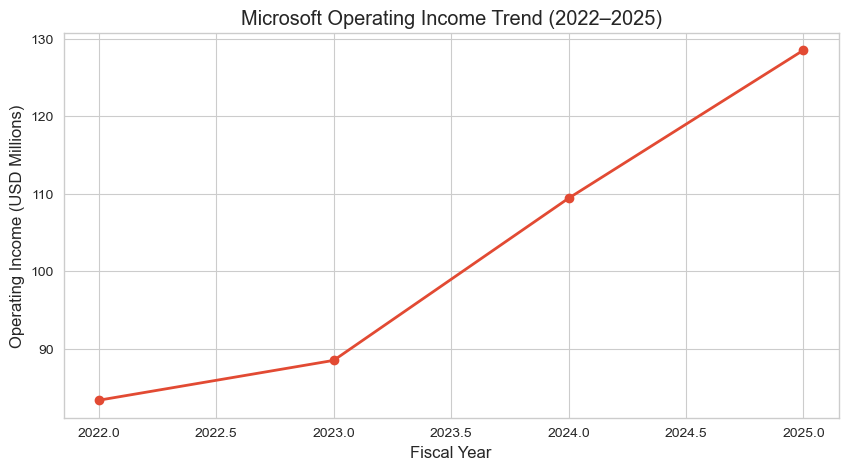

In [149]:
plt.figure(figsize=(10, 5))

plt.plot(
    operating_income.index,
    operating_income["Operating Income"],
    marker="o",
    linewidth=2
)

plt.title("Microsoft Operating Income Trend (2022–2025)")
plt.xlabel("Fiscal Year")
plt.ylabel("Operating Income (USD Millions)")

plt.grid(True)

plt.show()

#### Interpretation

Microsoft's operating income increased consistently throughout the analyzed period, indicating stronger operating performance and improved profitability from its core business activities.

The upward trend suggests that the company has been successful in expanding its operations while effectively managing operating expenses. As a result, Microsoft generated higher operating profits each year, reflecting a healthy and scalable business model.

Overall, the growth in operating income supports the view that Microsoft's core business remains financially strong and capable of sustaining long-term profitability.


### 4.6 Net Income Analysis



Net income represents the company's final profit after deducting all operating expenses, interest expenses, taxes, and other non-operating items.

As one of the most important profitability metrics, net income reflects the amount of earnings available to shareholders.

This section evaluates Microsoft's net income trend and its growth over the analyzed period.

In [151]:
net_income = financial_performance[
    ["Net Income"]
]

net_income

,Net Income
2022,72.74
2023,72.36
2024,88.14
2025,101.83


#### Net Income Trend Visualization

The following chart illustrates Microsoft's net income over the analyzed fiscal years.

Visualizing the trend helps assess whether the company has consistently improved its overall profitability.

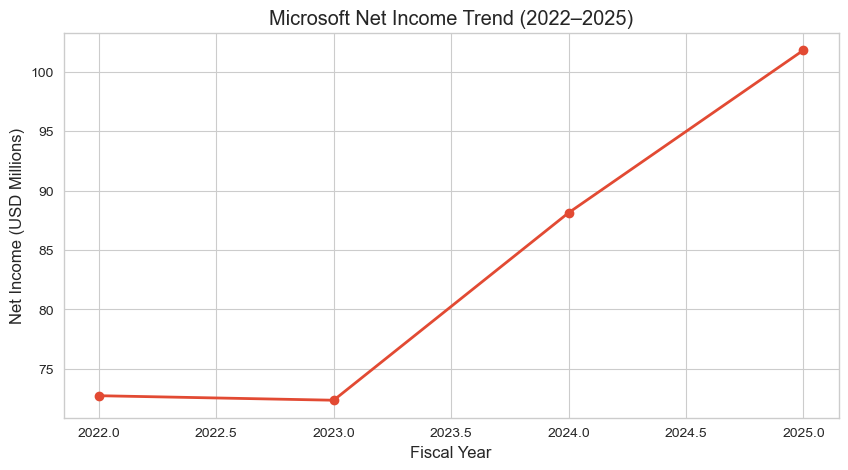

In [153]:
plt.figure(figsize=(10,5))

plt.plot(
    net_income.index,
    net_income["Net Income"],
    marker="o",
    linewidth=2
)

plt.title("Microsoft Net Income Trend (2022–2025)")
plt.xlabel("Fiscal Year")
plt.ylabel("Net Income (USD Millions)")

plt.grid(True)

plt.show()

#### Interpretation

Microsoft's net income increased consistently throughout the analyzed period, demonstrating the company's ability to generate higher earnings for its shareholders.

The upward trend indicates that Microsoft not only expanded its revenue but also effectively managed its operating expenses, financing costs, and taxes. This resulted in stronger overall profitability and reflects the company's financial strength.

Overall, the consistent growth in net income suggests that Microsoft's core business remains highly profitable and supports its long-term investment attractiveness.

## 5. Cash Flow Analysis


Cash flow analysis evaluates the amount of cash generated by Microsoft's business operations.

Unlike net income, which is based on accounting principles, cash flow measures the actual cash generated and used by the company.

Strong and consistent cash generation indicates financial stability, supports future investments, and provides the company with the flexibility to return value to shareholders through dividends and share repurchases.

### 5.1 Operating Cash Flow Analysis

Operating Cash Flow (OCF) represents the cash generated from Microsoft's core business operations during the fiscal year.

Unlike net income, which is based on accounting principles, operating cash flow measures the actual cash generated by the company's day-to-day operations.

A consistently growing operating cash flow indicates that Microsoft generates sufficient cash to support business expansion, invest in innovation, repay debt, and return value to shareholders.

In [157]:
cash_flow.index.tolist()

['Free Cash Flow',
 'Repurchase Of Capital Stock',
 'Repayment Of Debt',
 'Issuance Of Debt',
 'Issuance Of Capital Stock',
 'Capital Expenditure',
 'End Cash Position',
 'Beginning Cash Position',
 'Effect Of Exchange Rate Changes',
 'Changes In Cash',
 'Financing Cash Flow',
 'Cash Flow From Continuing Financing Activities',
 'Net Other Financing Charges',
 'Cash Dividends Paid',
 'Common Stock Dividend Paid',
 'Net Common Stock Issuance',
 'Common Stock Payments',
 'Common Stock Issuance',
 'Net Issuance Payments Of Debt',
 'Net Short Term Debt Issuance',
 'Short Term Debt Issuance',
 'Net Long Term Debt Issuance',
 'Long Term Debt Payments',
 'Long Term Debt Issuance',
 'Investing Cash Flow',
 'Cash Flow From Continuing Investing Activities',
 'Net Other Investing Changes',
 'Net Investment Purchase And Sale',
 'Sale Of Investment',
 'Purchase Of Investment',
 'Net Business Purchase And Sale',
 'Purchase Of Business',
 'Net PPE Purchase And Sale',
 'Purchase Of PPE',
 'Operating Ca

In [204]:
operating_cash_flow = cash_flow.loc[
    ["Operating Cash Flow"]
].T

operating_cash_flow.index = operating_cash_flow.index.year

operating_cash_flow = operating_cash_flow.sort_index()

operating_cash_flow["Operating Cash Flow"] = (
    operating_cash_flow["Operating Cash Flow"] / 1e9
).round(2)

operating_cash_flow["YoY Growth (%)"] = (
    operating_cash_flow["Operating Cash Flow"]
    .pct_change()
    .mul(100)
    .round(2)
)

operating_cash_flow

,Operating Cash Flow,YoY Growth (%)
2022,89.04,NaN
2023,87.58,-1.64
2024,118.55,35.36
2025,136.16,14.85


**Operating Cash Flow Trend Visualization**

The following chart illustrates Microsoft's operating cash flow over the analyzed fiscal years.

Visualizing the trend helps assess whether the company consistently generates sufficient cash from its core business operations.

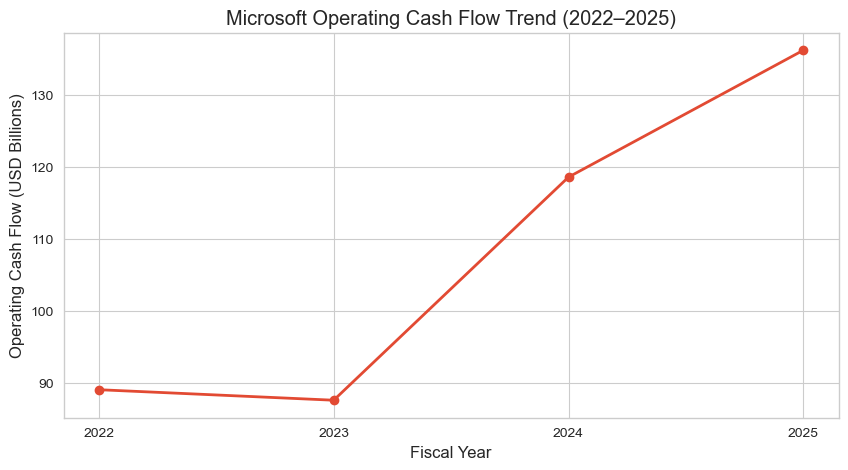

In [205]:
plt.figure(figsize = (10,5))

plt.plot(
        operating_cash_flow.index,
        operating_cash_flow["Operating Cash Flow"],
        marker = "o",
        linewidth = 2)

plt.xticks(operating_cash_flow.index)
plt.title("Microsoft Operating Cash Flow Trend (2022–2025)")
plt.xlabel("Fiscal Year")
plt.ylabel("Operating Cash Flow (USD Billions)")

plt.grid(True)

plt.show()

#### Interpretation

Microsoft's operating cash flow remained strong throughout the analyzed period, increasing from **USD 89.04 billion** in fiscal year 2022 to **USD 136.16 billion** in 2025.

Although operating cash flow declined slightly in 2023, the company experienced a strong recovery in 2024, followed by continued growth in 2025. This indicates that Microsoft's core operations generate substantial cash and that the business maintains a high level of financial quality.

Strong operating cash flow provides Microsoft with the financial flexibility to invest in innovation, finance capital expenditures, repay debt, distribute dividends, and repurchase shares without relying heavily on external financing.

Overall, the company's cash generation capacity supports its long-term financial stability and strengthens its investment profile.

### 5.2 Free Cash Flow Analysis



Free Cash Flow (FCF) represents the cash remaining after the company has generated operating cash flow and invested in capital expenditures required to maintain and expand its business.

Unlike operating cash flow, free cash flow measures the amount of cash that is truly available for shareholders, debt repayment, acquisitions, and future investments.

A consistently growing free cash flow is a strong indicator of financial strength and long-term value creation.

In [218]:
# Extract Free Cash Flow data from the cash_flow DataFrame and transpose it
free_cash_flow = cash_flow.loc[
    ["Free Cash Flow"]
].T

# Convert the index from datetime to year format for better readability
free_cash_flow.index = free_cash_flow.index.year

# Sort the data by year in ascending order
free_cash_flow = free_cash_flow.sort_index()

# Convert Free Cash Flow values from units to billions and round to 2 decimal places
free_cash_flow["Free Cash Flow"] = (
    free_cash_flow["Free Cash Flow"] / 1e9
).round(2)

# Calculate year-over-year growth percentage and round to 2 decimal places
free_cash_flow["YoY Growth (%)"] = (
    free_cash_flow["Free Cash Flow"]
    .pct_change()
    .mul(100)
    .round(2)
)

# Display the final DataFrame with Free Cash Flow and YoY Growth data
free_cash_flow

,Free Cash Flow,YoY Growth (%)
2022,65.15,NaN
2023,59.48,-8.70
2024,74.07,24.53
2025,71.61,-3.32


#### Free Cash Flow Trend Visualization

The following chart illustrates Microsoft's free cash flow over the analyzed fiscal years.

Visualizing the trend helps evaluate whether the company consistently generates excess cash after funding its operating activities and capital investments.

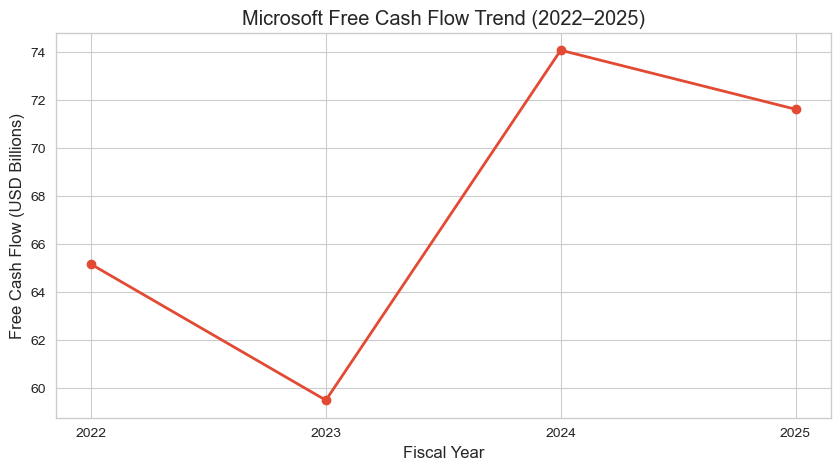

In [217]:
# Create a figure with specified dimensions (10 inches wide, 5 inches tall)
plt.figure(figsize=(10,5))

# Plot the free cash flow data as a line chart with circular markers
plt.plot(
    free_cash_flow.index,  # X-axis: fiscal years from the DataFrame index
    free_cash_flow["Free Cash Flow"],  # Y-axis: free cash flow values
    marker="o",  # Add circular markers at each data point
    linewidth=2  # Set line thickness to 2 points
)

# Set x-axis tick marks to match the DataFrame index values
plt.xticks(free_cash_flow.index)
# Add chart title
plt.title("Microsoft Free Cash Flow Trend (2022–2025)")
# Label the x-axis
plt.xlabel("Fiscal Year")
# Label the y-axis
plt.ylabel("Free Cash Flow (USD Billions)")

# Enable grid lines for better readability
plt.grid(True)

# Display the completed chart
plt.show()

#### Interpretation

Microsoft maintained a strong level of free cash flow throughout the analyzed period, generating between **USD 59.48 billion** and **USD 74.07 billion** annually.

Free cash flow declined in 2023, recovered significantly in 2024, and experienced a slight decrease in 2025. Despite these fluctuations, the company consistently generated substantial excess cash after funding its operating activities and capital expenditures.

Strong and stable free cash flow demonstrates Microsoft's ability to finance future growth, return capital to shareholders through dividends and share repurchases, and maintain financial flexibility without relying heavily on external financing.

Overall, Microsoft's cash generation capacity reinforces the company's strong financial position and supports its long-term investment attractiveness.

### 5.4 Free Cash Flow Margin Analysis



Free Cash Flow Margin measures the percentage of revenue that remains as free cash flow after funding the company's operations and capital expenditures.

The formula used is:

$$
\text{Free Cash Flow Margin} =
\frac{\text{Free Cash Flow}}{\text{Total Revenue}}
\times100
$$

A higher free cash flow margin indicates that the company converts a larger proportion of its revenue into cash available for shareholders, debt reduction, strategic acquisitions, and future investments.

In [219]:
# Calculate free cash flow margin as a percentage
# Formula: (Free Cash Flow / Total Revenue) * 100
free_cash_flow_margin = (
    free_cash_flow["Free Cash Flow"]
    /
    financial_performance["Total Revenue"]
) * 100

# Round the margin to 2 decimal places for better readability
free_cash_flow_margin = free_cash_flow_margin.round(2)

# Display the calculated free cash flow margin
free_cash_flow_margin

2022    32.86
2023    28.07
2024    30.22
2025    25.42
dtype: float64

#### Interpretation

Microsoft maintained a consistently strong free cash flow margin throughout the analyzed period, ranging from **25.42%** to **32.86%**.

Although the margin fluctuated across fiscal years, the company consistently converted approximately one-quarter to one-third of its revenue into free cash flow. This demonstrates Microsoft's ability to efficiently transform revenue into cash after covering both operating expenses and capital investments.

A high free cash flow margin provides Microsoft with significant financial flexibility, enabling the company to invest in innovation, pursue strategic acquisitions, reduce debt, and continue returning capital to shareholders through dividends and share repurchases.

Overall, the consistently high free cash flow margin reflects Microsoft's strong cash-generating capability and supports its long-term financial sustainability.

## 6. Financial Health Analysis

### 6.1 Cash Position

Cash represents one of the most important indicators of a company's financial strength.

A strong cash position provides financial flexibility by allowing the company to fund operations, invest in growth opportunities, repay debt, withstand periods of economic uncertainty, and return capital to shareholders.

This section examines Microsoft's cash position over the analyzed period.

In [214]:
balance_sheet.index.tolist()

['Ordinary Shares Number',
 'Share Issued',
 'Net Debt',
 'Total Debt',
 'Tangible Book Value',
 'Invested Capital',
 'Working Capital',
 'Net Tangible Assets',
 'Capital Lease Obligations',
 'Common Stock Equity',
 'Total Capitalization',
 'Total Equity Gross Minority Interest',
 'Stockholders Equity',
 'Gains Losses Not Affecting Retained Earnings',
 'Other Equity Adjustments',
 'Retained Earnings',
 'Capital Stock',
 'Common Stock',
 'Total Liabilities Net Minority Interest',
 'Total Non Current Liabilities Net Minority Interest',
 'Other Non Current Liabilities',
 'Tradeand Other Payables Non Current',
 'Non Current Deferred Liabilities',
 'Non Current Deferred Revenue',
 'Non Current Deferred Taxes Liabilities',
 'Long Term Debt And Capital Lease Obligation',
 'Long Term Capital Lease Obligation',
 'Long Term Debt',
 'Current Liabilities',
 'Other Current Liabilities',
 'Current Deferred Liabilities',
 'Current Deferred Revenue',
 'Current Debt And Capital Lease Obligation',
 'Cur

In [216]:
# Extract cash and cash equivalents data from balance sheet and transpose
cash_position = balance_sheet.loc[
    ["Cash Cash Equivalents And Short Term Investments"]
].T

# Convert datetime index to year for easier analysis
cash_position.index = cash_position.index.year

# Sort data chronologically by year
cash_position = cash_position.sort_index()

# Convert cash values from units to billions and round to 2 decimal places
cash_position["Cash Cash Equivalents And Short Term Investments"] = (
    cash_position["Cash Cash Equivalents And Short Term Investments"] / 1e9
).round(2)

# Calculate year-over-year growth percentage
cash_position["YoY Growth (%)"] = (
    cash_position["Cash Cash Equivalents And Short Term Investments"]
    .pct_change()
    .mul(100)
    .round(2)
)

cash_position

,Cash Cash Equivalents And Short Term Investments,YoY Growth (%)
2022,104.75,NaN
2023,111.26,6.21
2024,75.53,-32.11
2025,94.56,25.20


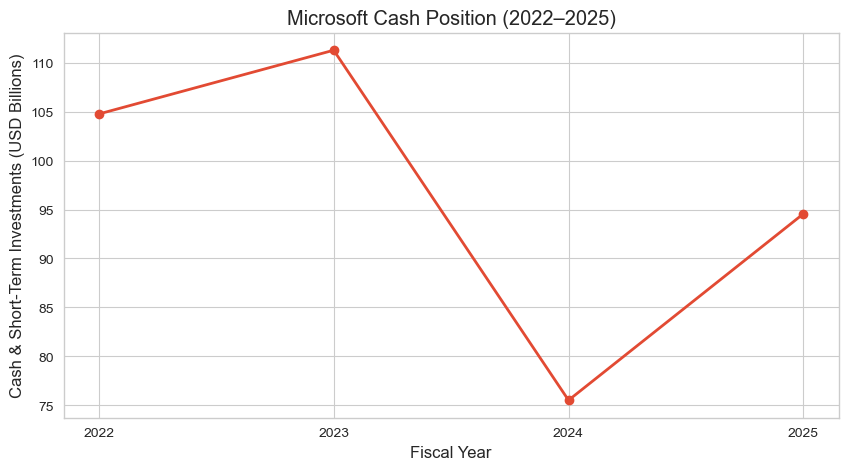

In [221]:
plt.figure(figsize=(10,5))

plt.plot(
    cash_position.index,
    cash_position["Cash Cash Equivalents And Short Term Investments"],
    marker="o",
    linewidth=2
)

plt.xticks(cash_position.index)
plt.title("Microsoft Cash Position (2022–2025)")
plt.xlabel("Fiscal Year")
plt.ylabel("Cash & Short-Term Investments (USD Billions)")

plt.grid(True)

plt.show()

#### Interpretation

Microsoft maintained a strong cash position throughout the analyzed period, with cash and short-term investments remaining above **USD 75 billion** in each fiscal year.

The company's cash position increased slightly in 2023 before declining in 2024. This decrease may indicate higher capital allocation toward strategic investments, acquisitions, capital expenditures, or shareholder returns. However, Microsoft recovered its cash position in 2025, demonstrating its strong ability to generate cash and rebuild liquidity.

Despite year-to-year fluctuations, maintaining a significant cash balance provides Microsoft with financial flexibility to support future growth opportunities, invest in innovation, manage economic uncertainty, and meet its financial obligations.

Overall, Microsoft's strong liquidity position indicates a financially resilient business with substantial internal resources.

### 6.2 Debt Analysis

Debt analysis evaluates Microsoft's level of financial leverage and its ability to manage outstanding obligations.

While debt can help companies finance growth, excessive leverage may increase financial risk. This section analyzes Microsoft's debt position and evaluates whether the company's debt level remains sustainable relative to its cash generation capacity.

In [223]:

total_debt = balance_sheet.loc[
    ["Total Debt"]
].T


total_debt.index = total_debt.index.year


total_debt = total_debt.sort_index()


total_debt["Total Debt"] = (
    total_debt["Total Debt"] / 1e9
).round(2)


total_debt

,Total Debt
2022,61.27
2023,59.96
2024,67.13
2025,60.59


#### Interpretation

Microsoft maintained a relatively stable debt level throughout the analyzed period, with total debt remaining within the range of **USD 59.96 billion to USD 67.13 billion**.

The slight increase in debt in 2024 was followed by a reduction in 2025, indicating that the company has maintained disciplined debt management.

When evaluated together with Microsoft's strong cash position and significant operating cash flow generation, the current debt level appears manageable. The company generates sufficient internal cash to meet its financial obligations without relying heavily on additional borrowing.

Overall, Microsoft's stable debt profile combined with strong cash generation indicates a low level of financial risk and supports the company's long-term financial stability.

### 6.2.1 Net Debt Analysis

In [225]:
net_debt = pd.DataFrame()

net_debt["Total Debt"] = total_debt["Total Debt"]

net_debt["Cash"] = cash_position[
    "Cash Cash Equivalents And Short Term Investments"
]

net_debt["Net Debt"] = (
    net_debt["Total Debt"] - net_debt["Cash"]
)

net_debt.round(2)

,Total Debt,Cash,Net Debt
2022,61.27,104.75,-43.48
2023,59.96,111.26,-51.30
2024,67.13,75.53,-8.40
2025,60.59,94.56,-33.97


#### Interpretation

Microsoft maintained a strong net cash position throughout the analyzed period, with cash and short-term investments exceeding total debt in every fiscal year.

Net debt remained negative from 2022 to 2025, ranging from **USD -8.40 billion** to **USD -51.30 billion**. This indicates that Microsoft holds more liquid assets than outstanding debt obligations.

Although the net cash position decreased in 2024 due to a reduction in cash reserves and an increase in debt, the company remained in a financially strong position and rebuilt its liquidity in 2025.

A consistent net cash position reduces financial risk and provides Microsoft with significant flexibility to invest in growth opportunities, manage economic uncertainty, and return capital to shareholders.

Overall, Microsoft's balance sheet demonstrates strong financial resilience and a conservative approach to leverage.

### 6.3 Liquidity Analysis

Liquidity analysis evaluates Microsoft's ability to meet its short-term financial obligations using its current assets.

This section focuses on two important liquidity ratios:

- Current Ratio: measures whether the company has enough current assets to cover current liabilities.
- Quick Ratio: measures short-term financial strength using the most liquid assets, excluding inventory.

These metrics help assess Microsoft's ability to manage short-term obligations and maintain financial stability.

In [228]:
liquidity = balance_sheet.loc[
    [
        "Current Assets",
        "Current Liabilities",
        "Cash Cash Equivalents And Short Term Investments",
        "Receivables"
    ]
].T

liquidity.index = liquidity.index.year

liquidity = liquidity.sort_index()

liquidity = (liquidity / 1e9).round(2)

liquidity

,Current Assets,Current Liabilities,Cash Cash Equivalents And Short Term Investments,Receivables
2022,169.68,95.08,104.75,44.26
2023,184.26,104.15,111.26,48.69
2024,159.73,125.29,75.53,56.92
2025,191.13,141.22,94.56,69.90


#### Current Ratio

Current Ratio measures whether a company has enough current assets to cover its short-term liabilities.

The formula is:
$$
[
Current\ Ratio = \frac{Current\ Assets}{Current\ Liabilities}
]
$$
A ratio above 1 indicates that the company has more current assets than short-term obligations.

In [229]:
liquidity["Current Ratio"] = (
    liquidity["Current Assets"] /
    liquidity["Current Liabilities"]
).round(2)

liquidity

,Current Assets,Current Liabilities,Cash Cash Equivalents And Short Term Investments,Receivables,Current Ratio
2022,169.68,95.08,104.75,44.26,1.78
2023,184.26,104.15,111.26,48.69,1.77
2024,159.73,125.29,75.53,56.92,1.27
2025,191.13,141.22,94.56,69.90,1.35


#### Quick Ratio

Quick Ratio provides a more conservative view of liquidity by considering only assets that can be quickly converted into cash.

The formula is:

$$[
Quick\ Ratio =
\frac{Cash + Receivables}{Current\ Liabilities}
]$$

A higher quick ratio indicates stronger short-term financial flexibility.

In [230]:
liquidity["Quick Ratio"] = (
    (
        liquidity["Cash Cash Equivalents And Short Term Investments"]
        +
        liquidity["Receivables"]
    )
    /
    liquidity["Current Liabilities"]
).round(2)

liquidity

,Current Assets,Current Liabilities,Cash Cash Equivalents And Short Term Investments,Receivables,Current Ratio,Quick Ratio
2022,169.68,95.08,104.75,44.26,1.78,1.57
2023,184.26,104.15,111.26,48.69,1.77,1.54
2024,159.73,125.29,75.53,56.92,1.27,1.06
2025,191.13,141.22,94.56,69.90,1.35,1.16


#### Liquidity Ratios Visualization

The following chart presents Microsoft's Current Ratio and Quick Ratio over the analyzed period.

Visualizing these ratios helps evaluate whether the company's short-term financial position has remained stable.

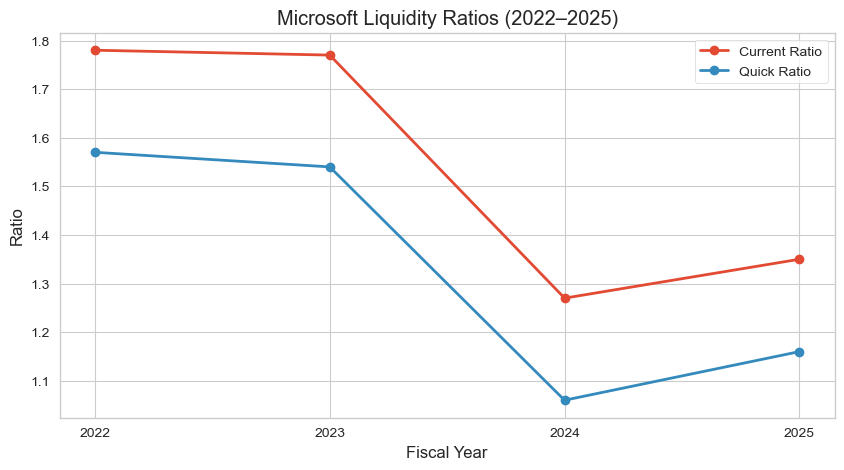

In [232]:
plt.figure(figsize=(10,5))

plt.plot(
    liquidity.index,
    liquidity["Current Ratio"],
    marker="o",
    linewidth=2,
    label="Current Ratio"
)

plt.plot(
    liquidity.index,
    liquidity["Quick Ratio"],
    marker="o",
    linewidth=2,
    label="Quick Ratio"
)

plt.xticks(liquidity.index)
plt.title("Microsoft Liquidity Ratios (2022–2025)")
plt.xlabel("Fiscal Year")
plt.ylabel("Ratio")

plt.legend()
plt.grid(True)

plt.show()

#### Interpretation

Microsoft maintained a positive liquidity position throughout the analyzed period, with both the Current Ratio and Quick Ratio remaining above 1.

The Current Ratio decreased from 1.78 in 2022 to 1.35 in 2025, while the Quick Ratio declined from 1.57 to 1.16 over the same period. This indicates that Microsoft's short-term liquidity position became somewhat weaker compared with previous years.

The decline in liquidity ratios was mainly driven by an increase in current liabilities and a temporary reduction in cash and short-term investments during 2024. However, the company continued to maintain sufficient liquid assets to cover its short-term obligations.

Overall, Microsoft's liquidity remains healthy, as the company maintains more current assets and liquid resources than short-term liabilities. Combined with strong operating cash flow generation and a net cash position, the company demonstrates solid short-term financial stability.

## 7. Valuation Analysis

### 7.1 Valuation Metrics

Valuation metrics help determine whether Microsoft's current stock price is reasonable relative to its financial performance and future growth expectations.

Unlike financial statement analysis, which focuses on the company's historical performance, valuation metrics reflect how the market currently values the business.

The following table presents Microsoft's key valuation metrics.

In [248]:
valuation_metrics = pd.DataFrame({
    "Metric": [
        "Trailing P/E",
        "Forward P/E",
        "Price-to-Sales",
        "Price-to-Book",
        "EV/EBITDA",
        "PEG Ratio"
    ],
    "Value": [
        msft.info["trailingPE"],
        msft.info["forwardPE"],
        msft.info["priceToSalesTrailing12Months"],
        msft.info["priceToBook"],
        msft.info["enterpriseToEbitda"],
        msft.info["pegRatio"]
    ]
}).round(2).set_index('Metric')

valuation_metrics

,Value
Metric,
Trailing P/E,23.47
Forward P/E,20.32
Price-to-Sales,9.19
Price-to-Book,7.06
EV/EBITDA,16.12
PEG Ratio,1.21


### 7.2 Price-to-Earnings (P/E) Ratio


The Price-to-Earnings (P/E) ratio measures how much investors are willing to pay for one dollar of the company's earnings.

It is one of the most widely used valuation metrics and reflects market expectations regarding future growth and profitability.

The formula is:

$$
P/E = \frac{\text{Market Price per Share}}{\text{Earnings per Share (EPS)}}
$$

A higher P/E ratio often indicates that investors expect stronger future growth, while a lower P/E ratio may suggest a more conservative market valuation.

#### Interpretation

Microsoft's trailing P/E ratio is **23.47**, indicating that investors are willing to pay approximately **23.47 USD** for every **1 USD** of the company's earnings generated over the past twelve months.

This valuation reflects strong investor confidence in Microsoft's long-term growth prospects, profitability, and competitive position. Compared with many mature companies, Microsoft's relatively high P/E ratio suggests that the market expects continued earnings growth, supported by its leadership in cloud computing, enterprise software, and artificial intelligence.

Overall, the P/E ratio indicates that Microsoft is valued at a premium, which is consistent with the company's strong financial performance and future growth expectations.

### 7.3 Forward Price-to-Earnings (Forward P/E) Ratio

In [250]:
forward_pe = valuation_metrics.loc["Forward P/E", "Value"]

print(f"Forward P/E Ratio: {forward_pe}")

Forward P/E Ratio: 20.32


#### Interpretation

Microsoft's Forward P/E ratio is **20.32**, which is lower than its Trailing P/E ratio of **23.47**.

This difference suggests that analysts expect Microsoft's earnings to increase in the future. As projected earnings grow while the current share price remains the same, the Forward P/E ratio decreases.

The lower Forward P/E indicates positive market expectations regarding Microsoft's future profitability, supported by continued growth in cloud computing, artificial intelligence, and enterprise software.

Overall, the Forward P/E ratio reinforces the view that investors expect Microsoft to continue delivering strong earnings growth over the coming years.

### 7.4 Enterprise Value to EBITDA (EV/EBITDA)

The Enterprise Value to EBITDA (EV/EBITDA) ratio measures the value of a company relative to its operating earnings before interest, taxes, depreciation, and amortization.

Unlike the P/E ratio, EV/EBITDA considers the company's entire value, including both equity and debt. As a result, it provides a more comprehensive measure of valuation and is widely used to compare companies with different capital structures.

The formula is:

$$
EV/EBITDA =
\frac{\text{Enterprise Value (EV)}}
{\text{EBITDA}}
$$

A lower EV/EBITDA ratio generally indicates a lower valuation relative to operating earnings, while a higher ratio suggests that investors are paying a premium for the company's operating performance.

In [252]:
ev_ebitda = valuation_metrics.loc["EV/EBITDA", "Value"]

print(f"EV/EBITDA: {ev_ebitda}")

EV/EBITDA: 16.12


#### Interpretation

Microsoft's EV/EBITDA ratio is **16.12**, indicating that the company's enterprise value is approximately **16.12 times** its annual EBITDA.

This multiple suggests that investors are willing to pay a premium for Microsoft's operating business, reflecting expectations of continued profitability, stable cash flow generation, and long-term growth.

Although the ratio is relatively high compared with many mature companies, it is supported by Microsoft's strong competitive position, recurring revenue streams, and leadership in cloud computing and artificial intelligence.

Overall, the EV/EBITDA ratio indicates that the market places a high value on Microsoft's operating performance and future growth potential.

### 7.5 Price-to-Sales (P/S) Ratio



The Price-to-Sales (P/S) ratio measures how much investors are willing to pay for one dollar of the company's revenue.

Unlike the P/E ratio, which is based on earnings, the P/S ratio focuses solely on revenue and is particularly useful for comparing companies with different profit margins.

The formula is:

$$
P/S =
\frac{\text{Market Capitalization}}
{\text{Total Revenue}}
$$

A higher P/S ratio indicates that investors place a higher value on each dollar of revenue, often reflecting strong growth expectations and confidence in the company's future profitability.

In [254]:
price_to_sales = valuation_metrics.loc["Price-to-Sales", "Value"]

print(f"Price-to-Sales Ratio: {price_to_sales}")

Price-to-Sales Ratio: 9.19


#### Interpretation

Microsoft's Price-to-Sales ratio is **9.19**, meaning that investors value the company at approximately **9.19 times** its annual revenue.

This relatively high valuation reflects strong confidence in Microsoft's ability to convert revenue into profits and cash flow. The company's high gross margins, operating margins, and free cash flow generation justify investors' willingness to pay a premium for each dollar of revenue.

Overall, the P/S ratio suggests that the market expects Microsoft to continue generating sustainable revenue growth and maintaining strong profitability.

### 7.6 Price-to-Book (P/B) Ratio

The Price-to-Book (P/B) ratio compares the company's market value with its book value (shareholders' equity).

It indicates how much investors are willing to pay for each dollar of the company's net assets.

The formula is:

$$
P/B =
\frac{\text{Market Price per Share}}
{\text{Book Value per Share}}
$$

A higher P/B ratio generally reflects strong investor confidence in the company's future growth, profitability, and ability to generate returns beyond the value of its recorded assets.

In [255]:
price_to_book = valuation_metrics.loc["Price-to-Book", "Value"]

print(f"Price-to-Book Ratio: {price_to_book}")

Price-to-Book Ratio: 7.06


#### Interpretation

Microsoft's Price-to-Book ratio is **7.06**, indicating that investors value the company at approximately **7.06 times** its book value.

This premium valuation reflects the market's confidence in Microsoft's ability to generate earnings well above the value of its recorded net assets. As a technology company, a significant portion of Microsoft's value comes from intangible assets such as software, intellectual property, cloud infrastructure, brand recognition, and its competitive market position, which are not fully reflected in book value.

Overall, the P/B ratio suggests that investors expect Microsoft to continue creating value beyond its accounting net assets.

### 7.7 PEG Ratio


The Price/Earnings-to-Growth (PEG) ratio adjusts the Price-to-Earnings (P/E) ratio by the company's expected earnings growth rate.

Unlike the P/E ratio, which considers only the relationship between price and earnings, the PEG ratio helps determine whether the company's valuation is justified by its expected growth.

The formula is:

$$
PEG =
\frac{P/E}
{\text{Expected Earnings Growth Rate}}
$$

A PEG ratio close to 1 is often interpreted as a valuation that is broadly aligned with the company's expected earnings growth. Values significantly above 1 may indicate a premium valuation relative to growth expectations, while values below 1 may suggest that the company is undervalued relative to its expected growth.

In [258]:
peg_ratio = valuation_metrics.loc["PEG Ratio", "Value"]

print(f"PEG Ratio: {peg_ratio}")

PEG Ratio: 1.21


#### Interpretation

Microsoft's PEG ratio is **1.21**, indicating that its market valuation is slightly above its expected earnings growth rate.

Although the ratio is above 1, it remains relatively close to this benchmark, suggesting that the company's premium valuation is largely supported by its expected future growth.

Given Microsoft's strong competitive position, consistent revenue growth, high profitability, and leadership in cloud computing and artificial intelligence, investors appear willing to pay a modest premium for the company's long-term growth potential.

Overall, the PEG ratio suggests that Microsoft's valuation is reasonably supported by its expected earnings growth rather than being driven solely by market optimism.

### 7.8 Overall Valuation Assessment


The valuation metrics collectively indicate that Microsoft is trading at a premium compared with many companies. However, this premium appears to be supported by the company's strong financial performance and future growth expectations.

Microsoft demonstrates consistent revenue growth, high profit margins, strong operating and free cash flow generation, a healthy balance sheet, and a net cash position. These characteristics justify why investors are willing to pay higher valuation multiples.

In addition, the Forward P/E ratio is lower than the Trailing P/E ratio, suggesting that analysts expect earnings to continue growing. The PEG ratio of **1.21** further indicates that Microsoft's valuation remains reasonably aligned with its expected growth rate.

Overall, the valuation analysis suggests that Microsoft is a high-quality company trading at a premium valuation, with that premium largely supported by its financial strength and long-term growth prospects.

### 7.9 Discounted Cash Flow (DCF) Valuation



While valuation multiples such as P/E and EV/EBITDA compare Microsoft with the market, the Discounted Cash Flow (DCF) model estimates the company's intrinsic value based on its expected future cash flows.

The DCF approach assumes that the value of a business is equal to the present value of the cash it is expected to generate in the future.

For simplicity, this analysis uses a five-year forecast based on Free Cash Flow (FCF), together with reasonable assumptions for the discount rate and terminal growth rate.

The following assumptions are used throughout the valuation model.

In [265]:
dcf_assumptions = pd.DataFrame({
    "Assumption": [
        "Forecast Period",
        "Annual FCF Growth Rate",
        "Discount Rate (WACC)",
        "Terminal Growth Rate"
    ],
    "Value": [
        "5 Years",
        "8%",
        "8.5%",
        "2.5%"
    ]
})

dcf_assumptions

,Assumption,Value
0,Forecast Period,5 Years
1,Annual FCF Growth Rate,8%
2,Discount Rate (WACC),8.5%
3,Terminal Growth Rate,2.5%


#### Assumptions

The DCF model requires several assumptions regarding future business performance.

For this project, simplified assumptions are used to demonstrate the valuation methodology rather than to produce a precise investment valuation.

These assumptions represent reasonable long-term estimates for a large, mature technology company such as Microsoft.

#### 7.9.1 Forecast Free Cash Flow

The first step in the DCF model is to estimate Microsoft's future Free Cash Flow (FCF).

Free Cash Flow represents the cash available after covering operating expenses and capital expenditures. It is commonly used in valuation models because it reflects the cash that can ultimately be distributed to investors or reinvested in the business.

For this analysis, future FCF is projected over the next five years using a constant annual growth rate of **8%**.

In [267]:
last_fcf = free_cash_flow.loc[2025, "Free Cash Flow"]

growth_rate = 0.08
forecast_years = 5

forecast = []

fcf = last_fcf

for year in range(2026, 2031):
    fcf *= (1 + growth_rate)

    forecast.append({
        "Year": year,
        "Projected Free Cash Flow (B USD)": round(fcf, 2)
    })

forecast_fcf = pd.DataFrame(forecast)

forecast_fcf

,Year,Projected Free Cash Flow (B USD)
0,2026,77.34
1,2027,83.53
2,2028,90.21
3,2029,97.42
4,2030,105.22


**Interpretation**

Based on an assumed annual growth rate of **8%**, Microsoft's projected Free Cash Flow increases steadily over the five-year forecast period.

The projected growth reflects expectations that Microsoft will continue expanding its cloud services, enterprise software, and artificial intelligence businesses while maintaining strong cash generation.

These projected cash flows serve as the foundation for the remaining steps of the DCF valuation model.

#### 7.9.2 Discount Future Cash Flows

Future cash flows are worth less than cash received today because of the time value of money.

To account for this, each projected Free Cash Flow is discounted to its present value using the assumed discount rate (WACC) of **8.5%**.

The present value of each future cash flow is calculated using the following formula:

$$
PV = \frac{FCF}{(1+r)^t}
$$

where:

- **PV** = Present Value
- **FCF** = Projected Free Cash Flow
- **r** = Discount Rate (8.5%)
- **t** = Number of years

In [269]:
discount_rate = 0.085

forecast_fcf["Discount Factor"] = [
    (1 + discount_rate) ** i
    for i in range(1, forecast_years + 1)
]

forecast_fcf["Present Value (B USD)"] = (
    forecast_fcf["Projected Free Cash Flow (B USD)"]
    / forecast_fcf["Discount Factor"]
).round(2)

forecast_fcf

,Year,Projected Free Cash Flow (B USD),Discount Factor,Present Value (B USD)
0,2026,77.34,1.085000,71.28
1,2027,83.53,1.177225,70.96
2,2028,90.21,1.277289,70.63
3,2029,97.42,1.385859,70.30
4,2030,105.22,1.503657,69.98


#### Interpretation

After applying the discount rate, each projected Free Cash Flow is converted into its present value.

Although Microsoft's projected Free Cash Flow increases over time, the present value of these cash flows grows more slowly because future cash flows are discounted to reflect the time value of money.

These discounted cash flows represent the estimated value of Microsoft's future cash generation in today's dollars.

#### 7.9.3 Terminal Value

Since companies are expected to continue operating beyond the explicit forecast period, the DCF model includes a Terminal Value to estimate the value of all future cash flows after the final forecast year.

The Terminal Value is calculated using the Gordon Growth Model, which assumes that Free Cash Flow will continue growing at a constant long-term rate.

The formula is:

$$
TV = \frac{FCF_{n+1}}{WACC-g}
$$

where:

- **TV** = Terminal Value
- **FCFₙ₊₁** = Free Cash Flow in the year following the forecast period
- **WACC** = Discount Rate
- **g** = Terminal Growth Rate

In [271]:
terminal_growth = 0.025

last_projected_fcf = forecast_fcf.loc[
    forecast_fcf.index[-1],
    "Projected Free Cash Flow (B USD)"
]

terminal_fcf = last_projected_fcf * (1 + terminal_growth)

terminal_value = terminal_fcf / (discount_rate - terminal_growth)

print(f"Terminal Value: {terminal_value:.2f} B USD")

Terminal Value: 1797.51 B USD


In [272]:
present_terminal_value = (
    terminal_value
    / ((1 + discount_rate) ** forecast_years)
)

print(f"Present Value of Terminal Value: {present_terminal_value:.2f} B USD")

Present Value of Terminal Value: 1195.42 B USD


#### 7.9.4 Enterprise Value

The Enterprise Value is calculated by combining the present value of the projected Free Cash Flows with the present value of the Terminal Value.

This represents the estimated value of Microsoft's operating business based on the DCF model.

The formula is:

$$
Enterprise\ Value =
\sum PV(FCF) + PV(Terminal\ Value)
$$

In [273]:
pv_fcf = forecast_fcf["Present Value (B USD)"].sum()

enterprise_value = pv_fcf + present_terminal_value

print(f"Present Value of Forecast Cash Flows: {pv_fcf:.2f} B USD")
print(f"Enterprise Value: {enterprise_value:.2f} B USD")

Present Value of Forecast Cash Flows: 353.15 B USD
Enterprise Value: 1548.57 B USD


**Interpretation**

The Enterprise Value represents the estimated value of Microsoft's operating business based on its projected future cash flows.

Most of the company's estimated value comes from the Terminal Value, which is expected for mature businesses with stable long-term cash flow generation.

This result reflects Microsoft's ability to generate significant cash flows well beyond the explicit five-year forecast period.

#### 7.9.5 Equity Value

Enterprise Value represents the value of Microsoft's operating business. To estimate the value attributable to shareholders, cash is added and total debt is subtracted.

The resulting Equity Value represents the estimated market value of Microsoft's equity based on the DCF model.

The formula is:

$$
Equity\ Value =
Enterprise\ Value
+
Cash
-
Debt
$$

In [275]:
cash = 94.56
debt = 60.59

equity_value = enterprise_value + cash - debt

print(f"Equity Value: {equity_value:.2f} B USD")

Equity Value: 1582.54 B USD


** Interpretation **

After adjusting Enterprise Value for Microsoft's cash and total debt, the estimated Equity Value is approximately **1.58 trillion USD**.

Microsoft's net cash position increases the value attributable to shareholders, as the company holds more cash and short-term investments than total debt.

The Equity Value serves as the basis for estimating the intrinsic value of each outstanding share.

### 7.9.6 Intrinsic Value per Share

The final step of the DCF model is to estimate the intrinsic value of a single share.

This is calculated by dividing the estimated Equity Value by the total number of shares outstanding.

The formula is:

$$
Intrinsic\ Value\ per\ Share =
\frac{Equity\ Value}
{Shares\ Outstanding}
$$

The resulting value can then be compared with the current market price to assess whether the stock appears undervalued, fairly valued, or overvalued under the assumptions of the DCF model.

In [277]:
shares_outstanding = msft.info["sharesOutstanding"] / 1e9

intrinsic_value = equity_value / shares_outstanding

print(f"Intrinsic Value per Share: ${intrinsic_value:.2f}")
print(f"Current Market Price: ${msft.info['currentPrice']:.2f}")

Intrinsic Value per Share: $213.04
Current Market Price: $393.82


**Interpretation**

Based on the assumptions used in this simplified DCF model, Microsoft's estimated intrinsic value is **213.04USD per share**, while the current market price is **$393.82 per share**.

Under these assumptions, the estimated intrinsic value is lower than the current market price, suggesting that Microsoft may be trading at a premium relative to this DCF valuation.

However, this conclusion should be interpreted with caution. The result depends heavily on the assumptions used for future Free Cash Flow growth, the discount rate (WACC), and the terminal growth rate. Small changes in these assumptions can materially affect the estimated intrinsic value.

Therefore, this simplified DCF model should be viewed as an educational valuation exercise rather than a definitive estimate of Microsoft's fair value.

### 7.10 Sensitivity Analysis

DCF valuation is highly dependent on the assumptions used in the model.

Small changes in the discount rate (WACC) and terminal growth rate can significantly affect the estimated intrinsic value of the company.

To evaluate the impact of these assumptions, a sensitivity analysis is performed by calculating Microsoft's intrinsic value under different WACC and terminal growth rate scenarios.

This analysis helps identify how the estimated valuation changes under different market conditions.

In [285]:
def calculate_dcf_value(wacc, terminal_growth):

    last_fcf = float(last_projected_fcf)

    terminal_fcf = last_fcf * (1 + terminal_growth)

    terminal_value = terminal_fcf / (wacc - terminal_growth)

    pv_terminal = terminal_value / ((1 + wacc) ** forecast_years)

    pv_fcf = 0

    for i, fcf in enumerate(
        forecast_fcf["Projected Free Cash Flow (B USD)"],
        start=1
    ):
        pv_fcf += fcf / ((1 + wacc) ** i)

    enterprise_value = pv_fcf + pv_terminal

    equity_value = enterprise_value + float(cash) - float(debt)

    intrinsic_value = equity_value / float(shares_outstanding)

    return round(intrinsic_value, 2)

In [286]:
wacc_values = [0.075, 0.085, 0.095]
growth_values = [0.02, 0.025, 0.03]


sensitivity_table = pd.DataFrame(
    index=[f"{w*100:.1f}% WACC" for w in wacc_values],
    columns=[f"{g*100:.1f}% Growth" for g in growth_values],
    dtype=float
)


for wacc in wacc_values:
    for growth in growth_values:
        sensitivity_table.loc[
            f"{wacc*100:.1f}% WACC",
            f"{growth*100:.1f}% Growth"
        ] = float(calculate_dcf_value(wacc, growth))


sensitivity_table

,2.0% Growth,2.5% Growth,3.0% Growth
7.5% WACC,236.43,255.71,279.28
8.5% WACC,199.93,213.04,228.52
9.5% WACC,173.20,182.58,193.41


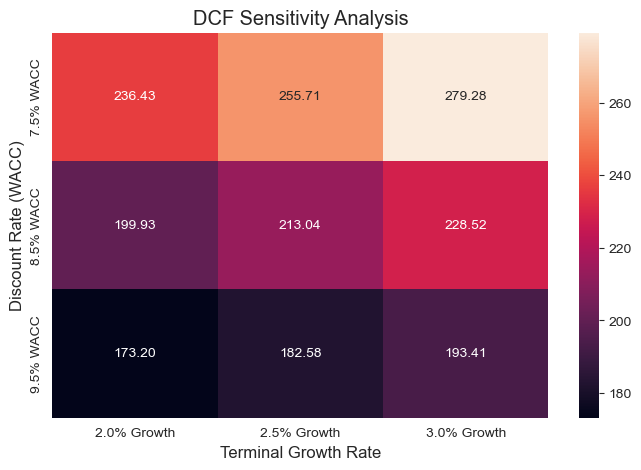

In [287]:
plt.figure(figsize=(8,5))

sns.heatmap(
    sensitivity_table.astype(float),
    annot=True,
    fmt=".2f"
)

plt.title("DCF Sensitivity Analysis")
plt.xlabel("Terminal Growth Rate")
plt.ylabel("Discount Rate (WACC)")
plt.show()


This section summarizes the key findings from the financial and valuation analyses to assess Microsoft's overall investment attractiveness.

The recommendation is based on the company's historical financial performance, profitability, cash flow generation, financial health, and current valuation metrics.

### 8.1 Summary of Key Findings

The financial analysis highlights several strengths of Microsoft's business:

- Revenue increased consistently throughout the analyzed period.
- Gross profit margin remained stable at approximately 69%, indicating strong pricing power and operational efficiency.
- Operating income and net income demonstrated sustained growth.
- Operating cash flow and free cash flow remained strong, supporting Microsoft's ability to invest in future growth while returning capital 
- The company maintained a healthy balance sheet, with a net cash position and liquidity ratios above 1, indicating low short-term financial risk.
- Valuation metrics suggest that Microsoft trades at premium multiples, but these appear to be supported by the company's strong fundamentals and expected earnings growth

### 8.2 Final Investment Assessment



Based on the analyses conducted in this project, Microsoft demonstrates strong financial performance, high profitability, robust cash generation, and solid financial stability.

Although the company's shares trade at premium valuation multiples, these valuations are broadly supported by Microsoft's consistent earnings growth, strong competitive position, and long-term growth opportunities.

Overall, the analysis suggests that Microsoft represents a financially strong company with attractive long-term business fundamentals. However, investment decisions should also consider factors beyond historical financial statements, including future market conditions, competitive dynamics, macroeconomic developments, and individual investment objectives.

## 9. Investment Risks



Although Microsoft demonstrates strong financial performance, significant profitability, and strong cash generation, several risks could impact future growth and valuation.

Understanding these risks is essential because investment decisions should consider not only potential returns but also possible downside scenarios.

### 9.1 Artificial Intelligence Competition

Microsoft has made significant investments in artificial intelligence through partnerships, cloud infrastructure, and AI-powered products.

However, the AI market is highly competitive, with companies such as Google, Amazon, and emerging AI-focused firms developing their own technologies.

Failure to maintain a strong competitive position in AI could negatively affect Microsoft's future growth expectations.

### 9.2 Valuation Risk

Microsoft trades at a premium valuation compared with many companies due to strong growth expectations and market confidence.

High valuation multiples create risk because any slowdown in revenue growth, cloud expansion, or profitability improvement could lead to a significant decline in the stock price.

### 9.3 Cloud Market Competition

Microsoft Azure is one of the company's main growth drivers.

However, the cloud computing market remains highly competitive, with major competitors including Amazon Web Services and Google Cloud.

Increasing competition or slower cloud adoption could negatively impact Microsoft's future revenue growth.

### 9.4 Regulatory Risk

As one of the world's largest technology companies, Microsoft faces regulatory scrutiny across different markets.

Potential antitrust regulations, data privacy requirements, or restrictions on technology companies could increase operational costs and limit business flexibility.

### 9.5 Macroeconomic Conditions

Economic uncertainty, changes in interest rates, and reduced enterprise spending could affect demand for Microsoft's products and services.

Higher interest rates may also negatively impact technology company valuations by increasing discount rates used in financial models.